**📌 Problem**

Can we predict who survived the Titanic disaster using passenger data?

**Why it’s valuable:** Classic starter — demonstrates preprocessing, feature engineering, classification, evaluation metrics.

In [1]:
"""
Goal:
Predict whether a passenger survived the Titanic disaster.

Target variable:
Survived (0 = No, 1 = Yes)

Type of problem:
Supervised Binary Classification
"""

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.chdir('/content/drive/My Drive/ml-portfolio/Project1')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [3]:
df=pd.read_csv("train.csv")


print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('Column descriptions:')
col_desc = {
    'Survived': 'Survival; Key- 0 = No, 1 = Yes',
    'Pclass': 'Ticket class; Key- 1 = 1st(Upper), 2 = 2nd(Middle), 3 = 3rd(Lower)',
    'Sex' : 'Sex',
    'Age' : 'Age in years',
    'SibSp': '# of siblings / spouses aboard the Titanic',
    'Parch': '# of parents / children aboard the Titanic',
    'Ticket': 'Ticket number',
    'Fare' : 'Passenger fare',
    'Cabin': 'Cabin number',
    'Embarked': 'Port of Embarkation; Key- C = Cherbourg, Q = Queenstown, S = Southampton'
}
for col, desc in col_desc.items():
    print(f'  {col:25s}: {desc}')

df.head()


Shape: 891 rows × 12 columns
Column descriptions:
  Survived                 : Survival; Key- 0 = No, 1 = Yes
  Pclass                   : Ticket class; Key- 1 = 1st(Upper), 2 = 2nd(Middle), 3 = 3rd(Lower)
  Sex                      : Sex
  Age                      : Age in years
  SibSp                    : # of siblings / spouses aboard the Titanic
  Parch                    : # of parents / children aboard the Titanic
  Ticket                   : Ticket number
  Fare                     : Passenger fare
  Cabin                    : Cabin number
  Embarked                 : Port of Embarkation; Key- C = Cherbourg, Q = Queenstown, S = Southampton


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Exploratory Data Analysis (EDA)

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


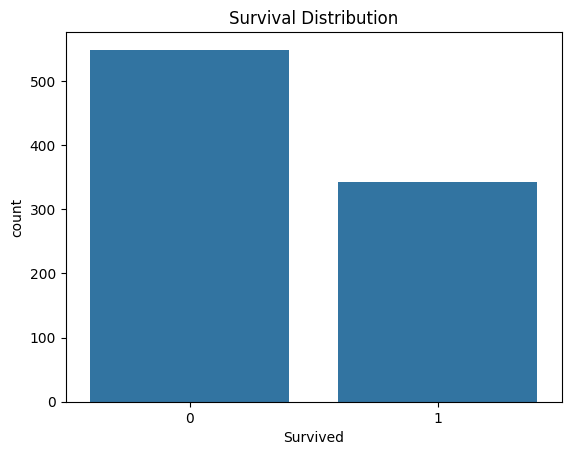

In [8]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

Checks class imbalance.

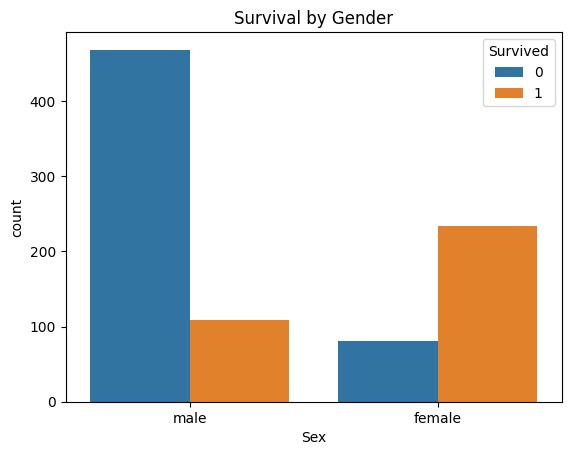

In [9]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

detected strong predictive patterns.

(females survived more → strong feature.)

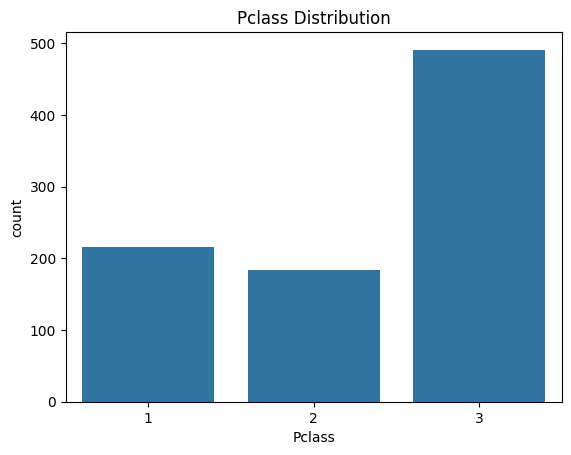

In [10]:
sns.countplot(x='Pclass', data=df)
plt.title("Pclass Distribution")
plt.show()

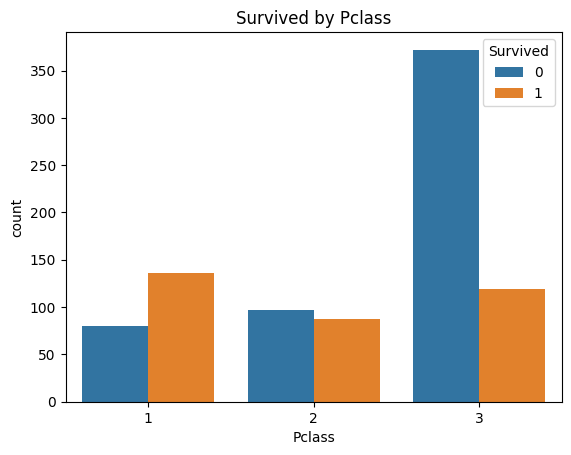

In [11]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survived by Pclass")
plt.show()

#Data Preprocessing

In [12]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

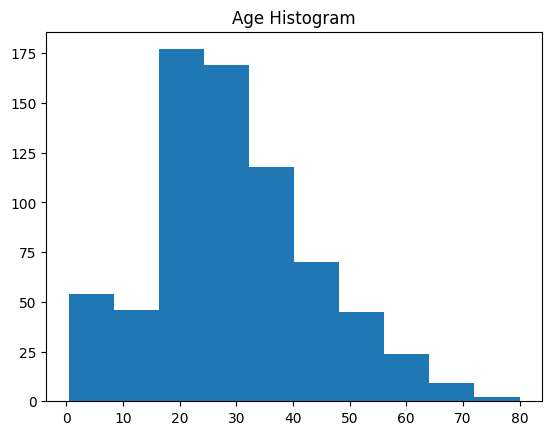

In [13]:
plt.hist(df['Age'], bins=10)
plt.title("Age Histogram")
plt.show()

In [14]:
df['Age'].median()

28.0

In [15]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_13144/4086271142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Age → median (robust to outliers)

In [16]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

Text(0.5, 1.0, 'Age Histogram')

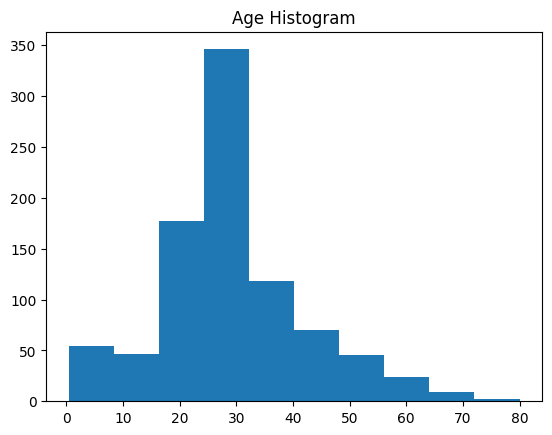

In [17]:
plt.hist(df['Age'], bins=10)
plt.title("Age Histogram")


In [18]:
df.drop(columns=['Cabin'], inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Cabin → too many missing

In [19]:
#df['Embarked'].unique()
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_13144/2038714569.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Embarked → most frequent category

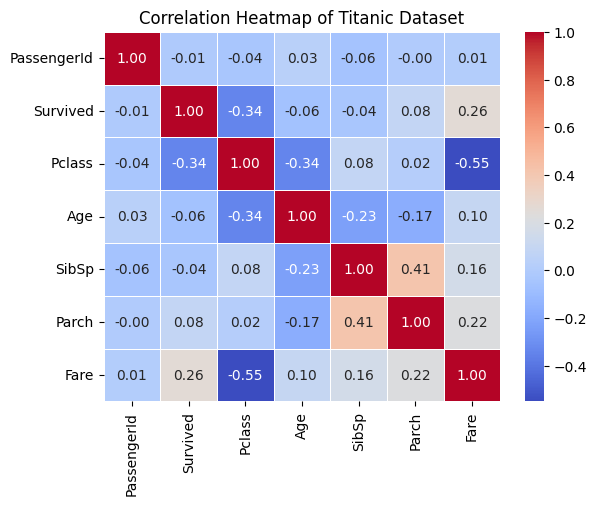

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Titanic Dataset")
plt.show()

#Feature Engineering

In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


Families likely survived together.

In [22]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,1,True,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,1,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,4,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,1,True,False,False


Converted Categorical to Numeric

#Model Training & Comparison

##Prepare Data

In [23]:
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling (For Logistic Regression)

* Logistic Regression uses gradient descent.
* Random Forest doesn’t need scaling.

##Baseline Model — Logistic Regression

In [26]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

#🔥 Evaluation

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1: 0.7638888888888888
ROC-AUC: 0.8817245817245817


ROC-AUC:

Better measure of ranking performance.

###Confusion Matrix

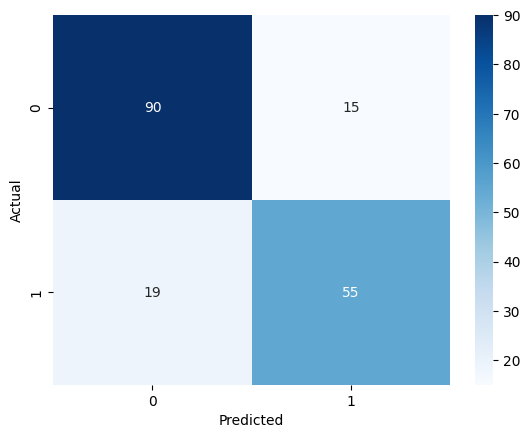

In [28]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Understand error types visually.

##Improve Model — Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

RF Accuracy: 0.8268156424581006
RF ROC-AUC: 0.8969755469755469


###Feature Importance (Random Forest)

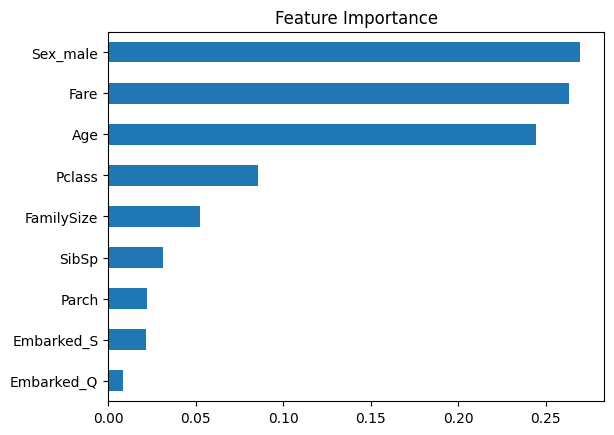

In [30]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [31]:
print("Train ROC-AUC:", roc_auc_score(y_train, lr.predict_proba(X_train_scaled)[:,1]))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

Train ROC-AUC: 0.8495781228990185
Test ROC-AUC: 0.8817245817245817


In [32]:
print("Train ROC-AUC:", roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]))
print("Test ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Train ROC-AUC: 0.997100645421541
Test ROC-AUC: 0.8969755469755469


#Conclusion

**Observations:** Final Section

* Logistic Regression ROC-AUC: 88.17%
* Random Forest ROC-AUC: 89.70%
* Important Features: Sex, Pclass, Fare
* Model Choice Reasoning:

**If performance is priority:** Random Forest achieved slightly higher ROC-AUC and captures nonlinear interactions between features, so I would select it for better predictive performance.
**If interpretability matters:** Logistic Regression performs almost as well while being simpler and more interpretable. Given the small performance difference, I would prefer Logistic Regression for easier explainability and lower complexity.
**Final:** Since performance difference is marginal (~1.5%), I would compare cross-validated scores to ensure stability. If Random Forest consistently outperforms, I would deploy it. Otherwise, I would choose Logistic Regression for simplicity and interpretability.

* Overfitting:
**In case of Random Forest**, Train score >> Test score, it has clear overfitting. trees memorize.
**In case of Logistic Regression**, Train score << Test score slightly, Good generalization.

#Cross Validation Score

In [33]:
from sklearn.model_selection import cross_val_score

In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr, X, y,
    cv=5,
    scoring='roc_auc'
)

print("CV Scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

CV Scores: [0.84637681 0.83181818 0.85046791 0.83843583 0.87554846]
Mean ROC-AUC: 0.8485294402055705
Std Dev: 0.014963731498831725


In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='roc_auc'
)

print("CV Scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

CV Scores: [0.8314888  0.80394385 0.91096257 0.84832888 0.89256748]
Mean ROC-AUC: 0.857458314580138
Std Dev: 0.03928592241840679


Mean ROC-AUC → average performance

Standard deviation → stability

Mean = 0.86

Std = 0.039

Small std → stable model.

Large std → unstable / high variance.